In [ ]:
import json
import os
import numpy as np
import geopandas as gpd
import pandas as pd
import datetime
from datetime import date, datetime
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import json
from shapely.geometry import shape
from tqdm import tqdm
import shapely

# PlanetScope Read

In [ ]:
MONTH = '12'

In [ ]:
planet_gdf = pd.read_csv('/content/drive/MyDrive/ST_intersection/2023_intersections/planet_2023/2023_'+MONTH+'.csv')
planet_gdf['planet_geometry'] = planet_gdf['geometry'].apply(shapely.wkt.loads)
planet_gdf = gpd.GeoDataFrame(planet_gdf, geometry='planet_geometry')
len(planet_gdf)

0

In [ ]:
def crosses_idl(polygon):
    # Extract longitude coordinates using NumPy for fast array processing
    longitudes = np.array([point[0] for point in polygon.exterior.coords])

    # Compute the absolute differences between successive longitudes
    diff = np.abs(np.diff(longitudes))

    # Check if any difference is greater than 180, indicating a crossing
    return np.any(diff > 180)

planet_gdf['crosses_idl'] = planet_gdf['planet_geometry'].apply(crosses_idl)
planet_gdf = planet_gdf[planet_gdf['crosses_idl'] == False]
len(planet_gdf)

241026

In [ ]:
planet_gdf['capture_time'] = pd.to_datetime(planet_gdf['capture_time'], format='ISO8601', utc=True)
planet_gdf['capture_time']

0        2023-11-10 22:36:03.562899+00:00
1        2023-11-01 22:57:16.314635+00:00
2        2023-11-05 23:02:39.385508+00:00
3        2023-11-05 21:59:00.672037+00:00
4        2023-11-02 22:45:14.428058+00:00
                       ...               
241021   2023-11-01 22:40:47.831737+00:00
241022   2023-11-01 22:40:52.368328+00:00
241023   2023-11-01 22:51:58.426451+00:00
241024   2023-11-01 22:52:00.689462+00:00
241025   2023-11-01 22:45:28.077455+00:00
Name: capture_time, Length: 241026, dtype: datetime64[ns, UTC]

In [ ]:
planet_gdf_chunk = planet_gdf.resample('D', on='capture_time')
planet_gdf_chunk_list = list(planet_gdf_chunk)
for planet_chunk in planet_gdf_chunk_list:
    print(planet_chunk[0], planet_chunk[1].shape[0])

2023-11-01 00:00:00+00:00 29696
2023-11-02 00:00:00+00:00 27340
2023-11-03 00:00:00+00:00 24066
2023-11-04 00:00:00+00:00 20967
2023-11-05 00:00:00+00:00 17964
2023-11-06 00:00:00+00:00 18562
2023-11-07 00:00:00+00:00 16672
2023-11-08 00:00:00+00:00 15117
2023-11-09 00:00:00+00:00 12886
2023-11-10 00:00:00+00:00 11088
2023-11-11 00:00:00+00:00 9360
2023-11-12 00:00:00+00:00 9083
2023-11-13 00:00:00+00:00 7538
2023-11-14 00:00:00+00:00 5685
2023-11-15 00:00:00+00:00 4511
2023-11-16 00:00:00+00:00 3509
2023-11-17 00:00:00+00:00 2238
2023-11-18 00:00:00+00:00 1774
2023-11-19 00:00:00+00:00 1264
2023-11-20 00:00:00+00:00 950
2023-11-21 00:00:00+00:00 533
2023-11-22 00:00:00+00:00 179
2023-11-23 00:00:00+00:00 40
2023-11-24 00:00:00+00:00 4


# Landsat 8 Read

In [ ]:
l8_gdf = pd.read_csv('/content/drive/MyDrive/ST_intersection/l8s2_intersection/l8_metadata_export_wkt.csv')
l8_gdf['geometry'] = l8_gdf['geometry'].apply(shapely.wkt.loads)
l8_gdf = gpd.GeoDataFrame(l8_gdf, geometry='geometry')
len(l8_gdf)

1699601

In [ ]:
l8_gdf['crosses_idl'] = l8_gdf['geometry'].apply(crosses_idl)
l8_gdf = l8_gdf[l8_gdf['crosses_idl'] == False]
len(l8_gdf)

1699601

In [ ]:
l8_gdf['timestamp'] = pd.to_datetime(l8_gdf['timestamp'], format='ISO8601', utc=True)
l8_gdf['timestamp']

0         2014-06-09 14:08:03+00:00
1         2014-06-25 14:08:05+00:00
2         2014-07-11 14:08:14+00:00
3         2014-07-27 14:08:17+00:00
4         2014-08-12 14:08:26+00:00
                     ...           
1699596   2023-05-26 15:38:48+00:00
1699597   2023-06-27 15:39:03+00:00
1699598   2023-07-13 15:39:12+00:00
1699599   2023-08-30 15:39:29+00:00
1699600   2024-04-10 15:39:04+00:00
Name: timestamp, Length: 1699601, dtype: datetime64[ns, UTC]

In [ ]:
l8_gdf_chunk = l8_gdf.resample('D', on='timestamp')
l8_gdf_chunk_list = list(l8_gdf_chunk)
for l8_gdf_chunk in l8_gdf_chunk_list:
    print(l8_gdf_chunk[0], l8_gdf_chunk[1].shape[0])

2013-03-18 00:00:00+00:00 38
2013-03-19 00:00:00+00:00 107
2013-03-20 00:00:00+00:00 106
2013-03-21 00:00:00+00:00 113
2013-03-22 00:00:00+00:00 132
2013-03-23 00:00:00+00:00 147
2013-03-24 00:00:00+00:00 214
2013-03-25 00:00:00+00:00 185
2013-03-26 00:00:00+00:00 193
2013-03-27 00:00:00+00:00 242
2013-03-28 00:00:00+00:00 253
2013-03-29 00:00:00+00:00 213
2013-03-30 00:00:00+00:00 212
2013-03-31 00:00:00+00:00 190
2013-04-01 00:00:00+00:00 286
2013-04-02 00:00:00+00:00 335
2013-04-03 00:00:00+00:00 319
2013-04-04 00:00:00+00:00 292
2013-04-05 00:00:00+00:00 259
2013-04-06 00:00:00+00:00 107
2013-04-07 00:00:00+00:00 296
2013-04-08 00:00:00+00:00 268
2013-04-09 00:00:00+00:00 327
2013-04-10 00:00:00+00:00 315
2013-04-11 00:00:00+00:00 321
2013-04-12 00:00:00+00:00 314
2013-04-13 00:00:00+00:00 361
2013-04-14 00:00:00+00:00 349
2013-04-15 00:00:00+00:00 341
2013-04-16 00:00:00+00:00 336
2013-04-17 00:00:00+00:00 315
2013-04-18 00:00:00+00:00 331
2013-04-19 00:00:00+00:00 317
2013-04-20 

# ST_Join

In [ ]:
def spatial_join_and_filter(gdf1_chunk, gdf2_chunk, time_diff=24):
    # Perform spatial join
    joined = gpd.sjoin(gdf1_chunk, gdf2_chunk, how="inner", predicate="within")
    # Filter based on time difference (assuming 'timestamp' columns in both)
    joined['time_diff'] = (joined['capture_time'] - joined['timestamp']).abs()
    result = joined[joined['time_diff'] < pd.Timedelta(hours=time_diff)]
    return result

In [ ]:
dict1 = {l[0]: l[1] for l in planet_gdf_chunk_list}
dict2 = {l[0]: l[1] for l in l8_gdf_chunk_list}
combined_lists_dict = {key: (dict1[key], dict2[key]) for key in dict1 if key in dict2}

In [ ]:
results = []
for date in combined_lists_dict:
    st_chunk = spatial_join_and_filter(combined_lists_dict[date][0], combined_lists_dict[date][1])
    results.append(st_chunk)

In [ ]:
result = pd.concat(results)
result.shape[0]

2371

In [ ]:
result

,Unnamed: 0,_links,_permissions,assets,geometry,id,properties,type,acquired,anomalous_pixels,...,planet_geometry,crosses_idl_left,index_right,system:index,cloud_cover_right,sun_azimuth_right,sun_elevation_right,timestamp,crosses_idl_right,time_diff
213587,0,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...","POLYGON ((138.2875389008921 61.06908193603172,...",20231101_004343_66_2445,"{'acquired': '2023-11-01T00:43:43.66497Z', 'an...",Feature,2023-11-01T00:43:43.66497Z,0,...,"POLYGON ((138.28754 61.06908, 138.17813 60.889...",False,629817,LC08_114018_20231101,8.75,171.648532,15.306803,2023-11-01 01:52:32+00:00,False,0 days 01:08:48.335030
213585,248,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((138.20260706041634 60.93057873991876...,20231101_004345_93_2445,"{'acquired': '2023-11-01T00:43:45.934694Z', 'a...",Feature,2023-11-01T00:43:45.934694Z,0,...,"POLYGON ((138.20261 60.93058, 138.09446 60.750...",False,629817,LC08_114018_20231101,8.75,171.648532,15.306803,2023-11-01 01:52:32+00:00,False,0 days 01:08:46.065306
213578,239,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((138.11874894994375 60.79159965782109...,20231101_004348_20_2445,"{'acquired': '2023-11-01T00:43:48.204417Z', 'a...",Feature,2023-11-01T00:43:48.204417Z,0,...,"POLYGON ((138.11875 60.79160, 138.01205 60.611...",False,629817,LC08_114018_20231101,8.75,171.648532,15.306803,2023-11-01 01:52:32+00:00,False,0 days 01:08:43.795583
213588,1,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((138.03636669045733 60.65237189882236...,20231101_004350_47_2445,"{'acquired': '2023-11-01T00:43:50.474141Z', 'a...",Feature,2023-11-01T00:43:50.474141Z,0,...,"POLYGON ((138.03637 60.65237, 137.92959 60.472...",False,629817,LC08_114018_20231101,8.75,171.648532,15.306803,2023-11-01 01:52:32+00:00,False,0 days 01:08:41.525859
213575,236,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((137.95432621509542 60.51347238161698...,20231101_004352_74_2445,"{'acquired': '2023-11-01T00:43:52.74381Z', 'an...",Feature,2023-11-01T00:43:52.74381Z,0,...,"POLYGON ((137.95433 60.51347, 137.84907 60.333...",False,629817,LC08_114018_20231101,8.75,171.648532,15.306803,2023-11-01 01:52:32+00:00,False,0 days 01:08:39.256190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60086,1,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((-72.81553175003712 59.43709380966723...,20231109_151541_78_241e,"{'acquired': '2023-11-09T15:15:41.786907Z', 'a...",Feature,2023-11-09T15:15:41.786907Z,0,...,"POLYGON ((-72.81553 59.43709, -72.90921 59.271...",False,111832,LC08_017019_20231109,46.60,170.969384,14.012945,2023-11-09 15:53:21+00:00,False,0 days 00:37:39.213093
60076,235,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...",POLYGON ((-72.88637666492491 59.31184600213142...,20231109_151543_81_241e,"{'acquired': '2023-11-09T15:15:43.816701Z', 'a...",Feature,2023-11-09T15:15:43.816701Z,0,...,"POLYGON ((-72.88638 59.31185, -72.97942 59.146...",False,111832,LC08_017019_20231109,46.60,170.969384,14.012945,2023-11-09 15:53:21+00:00,False,0 days 00:37:37.183299
60047,198,{'_self': 'https://api.planet.com/data/v1/item...,"['assets.basic_analytic_4b:download', 'assets....","['basic_analytic_4b', 'basic_analytic_4b_rpc',...","POLY

In [ ]:
final_result_subset = result[['id','cloud_percent', 'snow_ice_percent', 'capture_time', 'planet_geometry', 'system:index', 'cloud_cover_right', 'timestamp', 'geometry', 'time_diff']]

final_result_subset.to_csv(f'/content/drive/MyDrive/ST_intersection/2023_{MONTH}_l8ps_intersection_result_within_24.csv')

# Aggregate

In [ ]:
agg_results = []
nums = []
for month in range(1, 10):

    st_gdf = pd.read_csv(f'/content/drive/MyDrive/ST_intersection/2023_{month+1}_l8ps_intersection_result_within_24.csv')
    st_gdf['planet_geometry'] = st_gdf['planet_geometry'].apply(shapely.wkt.loads)
    st_gdf = gpd.GeoDataFrame(st_gdf, geometry='planet_geometry')
    nums.append(len(st_gdf))

    agg_results.append(st_gdf)

final_agg_result = pd.concat(agg_results)
final_agg_result.shape[0]

2208268

In [ ]:
final_agg_result['time_interval'] = pd.to_timedelta(final_agg_result['time_diff']).dt.seconds/3600  # This will convert the time delta into days
print(final_agg_result['time_interval'])

0         0.916111
1         0.915556
2         0.793889
3         0.793333
4         0.792500
            ...   
109915    0.626667
109916    0.626111
109917    0.064167
109918    0.063333
109919    0.062778
Name: time_interval, Length: 2208268, dtype: float64


In [ ]:
filtered_result = final_agg_result[final_agg_result['time_interval']< 0.05/60]
filtered_result.to_csv('/content/drive/MyDrive/ST_intersection/less_than_3s.csv')
filtered_result.shape[0]

1134

In [ ]:
filtered_result['centroid'] = filtered_result['planet_geometry'].centroid

/usr/local/lib/python3.10/dist-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


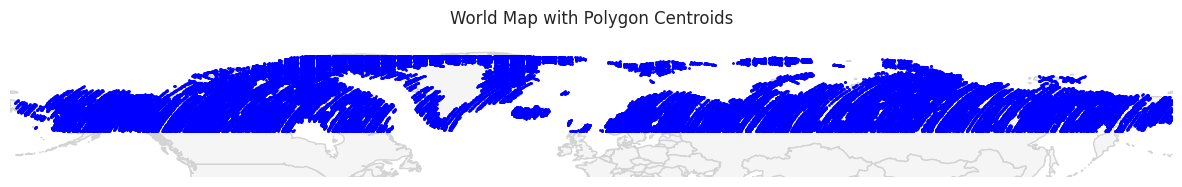

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")

# Load US counties shapefile
us_counties = gpd.read_file("/content/drive/MyDrive/ST_intersection/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

# Plot the world map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
us_counties.plot(ax=ax, color='whitesmoke', edgecolor='lightgray')  # Using lighter colors for background

# Plot centroids
gdf_centroids = filtered_result['centroid']
gdf_centroids.plot(ax=ax, color='blue', marker='o', markersize=1)  # Plot as red dots

# Set axis
ax.set_axis_off()
ax.set_xlim([-180, 180])
ax.set_ylim([45, 90])

plt.title('World Map with Polygon Centroids')

plt.show()